# WSI - Ćwiczenie 2: Algorytmy Ewolucyjne
**Optymalizacja warunków w szklarniach pomidorów (Solanum lycopersicum L.)**

Celem ćwiczenia jest minimalizacja funkcji błędu kalibracji (będącej modyfikacją funkcji Rastrigina) przy użyciu dwóch różnych podejść ewolucyjnych. Limit ewaluacji funkcji celu wynosi równe 9000. Wymiarowość problemu to 10 parametrów sterownika klimatu.

Rozpatrujemy dwa przypadki:
* **Przypadek A:** Klasyczny Algorytm Genetyczny (SGA) z kodowaniem binarnym (8 bitów na parametr), selekcją turniejową, krzyżowaniem dwupunktowym i mutacją binarną.
* **Przypadek B:** Strategia Ewolucyjna (ES) z reprezentacją rzeczywistą w schemacie $(\mu, 100)$, krzyżowaniem arytmetycznym i mutacją gaussowską z samoadaptacją parametru $\sigma$.

In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

# Import algorytmów z przygotowanych plików
from genetic_algorythym.genetic_algorythym import genetic_evolution
from genetic_algorythym.genetic_algorythym_prameters import return_genetic_algorithm_parameters

from evolution_algorythym.evolution_algorytym import EvolutionStrategy, RealChromosome
from evolution_algorythym.evolution_algorythym_prameters import return_evolutionary_strategy_parameters

# Ustawienia ogólne
MAX_EVALUATIONS = 9000
DIMENSIONS = 10

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Przypadek A: Algorytm Genetyczny (Kodowanie Binarne)
Zgodnie z poleceniem testujemy 3 różne wielkości turnieju $k$. Parametry:
* Populacja: 100
* Liczba pokoleń: 90 (daje to 9000 ewaluacji, ponieważ w każdym pokoleniu krzyżujemy do uzyskania populacji wielkości 100).
* Prawdopodobieństwo mutacji: $p_m = 1/L$, gdzie $L = 80$ (10 parametrów * 8 bitów).

In [6]:
# Pobranie domyślnych parametrów i nadpisanie ich na potrzeby eksperymentu
ga_params = return_genetic_algorithm_parameters()
ga_params["population_size"] = 100
ga_params["generations"] = MAX_EVALUATIONS // 100  # 90 pokoleń

# Wartości rozmiaru turnieju do przetestowania
k_values = [2, 5, 10]
ga_results_history = {}
ga_best_fitnesses = {}

for k in k_values:
    print(f"Uruchamianie GA dla rozmiaru turnieju k={k}...")
    ga_params["tournament_size"] = k
    
    ga = genetic_evolution(**ga_params)
    
    # Zakładamy, że metoda genetic_algorithm została poprawiona, aby zwracać 3 elementy
    # Jeśli zwraca tylko dwa, poniższy kod wymaga dostosowania (np. zapisywania historii z logów)
    best_chrom, best_fit, history = ga.genetic_algorithm() 
    
    ga_results_history[k] = history
    ga_best_fitnesses[k] = best_fit

print("\nWyniki dla Przypadku A:")
for k, fit in ga_best_fitnesses.items():
    print(f"Turniej k={k} -> Najlepszy błąd: {fit:.4f}")


Uruchamianie GA dla rozmiaru turnieju k=2...
Pokolenie   0 | Najlepszy dotychczasowy wynik (błąd): 28.0000
Pokolenie   1 | Najlepszy dotychczasowy wynik (błąd): 28.0000
Pokolenie   2 | Najlepszy dotychczasowy wynik (błąd): 28.0000
Pokolenie   3 | Najlepszy dotychczasowy wynik (błąd): 28.0000
Pokolenie   4 | Najlepszy dotychczasowy wynik (błąd): 28.0000
Pokolenie   5 | Najlepszy dotychczasowy wynik (błąd): 28.0000
Pokolenie   6 | Najlepszy dotychczasowy wynik (błąd): 27.0000
Pokolenie   7 | Najlepszy dotychczasowy wynik (błąd): 24.0000
Pokolenie   8 | Najlepszy dotychczasowy wynik (błąd): 24.0000
Pokolenie   9 | Najlepszy dotychczasowy wynik (błąd): 24.0000
Pokolenie  10 | Najlepszy dotychczasowy wynik (błąd): 24.0000
Pokolenie  11 | Najlepszy dotychczasowy wynik (błąd): 22.0000
Pokolenie  12 | Najlepszy dotychczasowy wynik (błąd): 22.0000
Pokolenie  13 | Najlepszy dotychczasowy wynik (błąd): 22.0000
Pokolenie  14 | Najlepszy dotychczasowy wynik (błąd): 22.0000
Pokolenie  15 | Najlepszy

## Przypadek B: Strategia Ewolucyjna $(\mu, 100)$
Testujemy 3 różne progi selekcji najlepszych osobników z puli ($\mu$). Zgodnie ze schematem $\lambda = 100$. 
Liczba pokoleń to 90 (90 pokoleń * 100 ewaluacji potokowych dzieci = 9000).

In [11]:
es_config = return_evolutionary_strategy_parameters()
es_config["lambda_"] = 100
es_config["generations"] = MAX_EVALUATIONS // 100 # 90 pokoleń

# Wstrzyknięcie zmiennych klasowych wymaganych przez RealChromosome
RealChromosome.num_params = es_config["num_params"]
RealChromosome.sigma_lower_bound = es_config["sigma_lower_bound"]

# Wartości mu do przetestowania
mu_values = [5, 15, 30]
es_results_history = {}
es_best_fitnesses = {}

for mu in mu_values:
    print(f"Uruchamianie Strategii Ewolucyjnej dla mu={mu}...")
    es = EvolutionStrategy(mu=mu, config=es_config)
    
    best_ind, history = es.run()
    
    es_results_history[mu] = history
    es_best_fitnesses[mu] = best_ind.fitness

print("\nWyniki dla Przypadku B:")
for mu, fit in es_best_fitnesses.items():
    print(f"Pula mu={mu} -> Najlepszy błąd: {fit:.4f}")

Uruchamianie Strategii Ewolucyjnej dla mu=5...
Uruchamianie Strategii Ewolucyjnej dla mu=15...
Uruchamianie Strategii Ewolucyjnej dla mu=30...

Wyniki dla Przypadku B:
Pula mu=5 -> Najlepszy błąd: 2.9699
Pula mu=15 -> Najlepszy błąd: 2.9699
Pula mu=30 -> Najlepszy błąd: 0.9900


## Wizualizacja Wyników i Analiza
Poniżej znajduje się zestawienie konwergencji obu algorytmów. Ze względu na charakter funkcji celu (Rastrigin) zastosowano skalę logarytmiczną na osi Y, co ułatwia obserwację zachowania algorytmów blisko optimum.

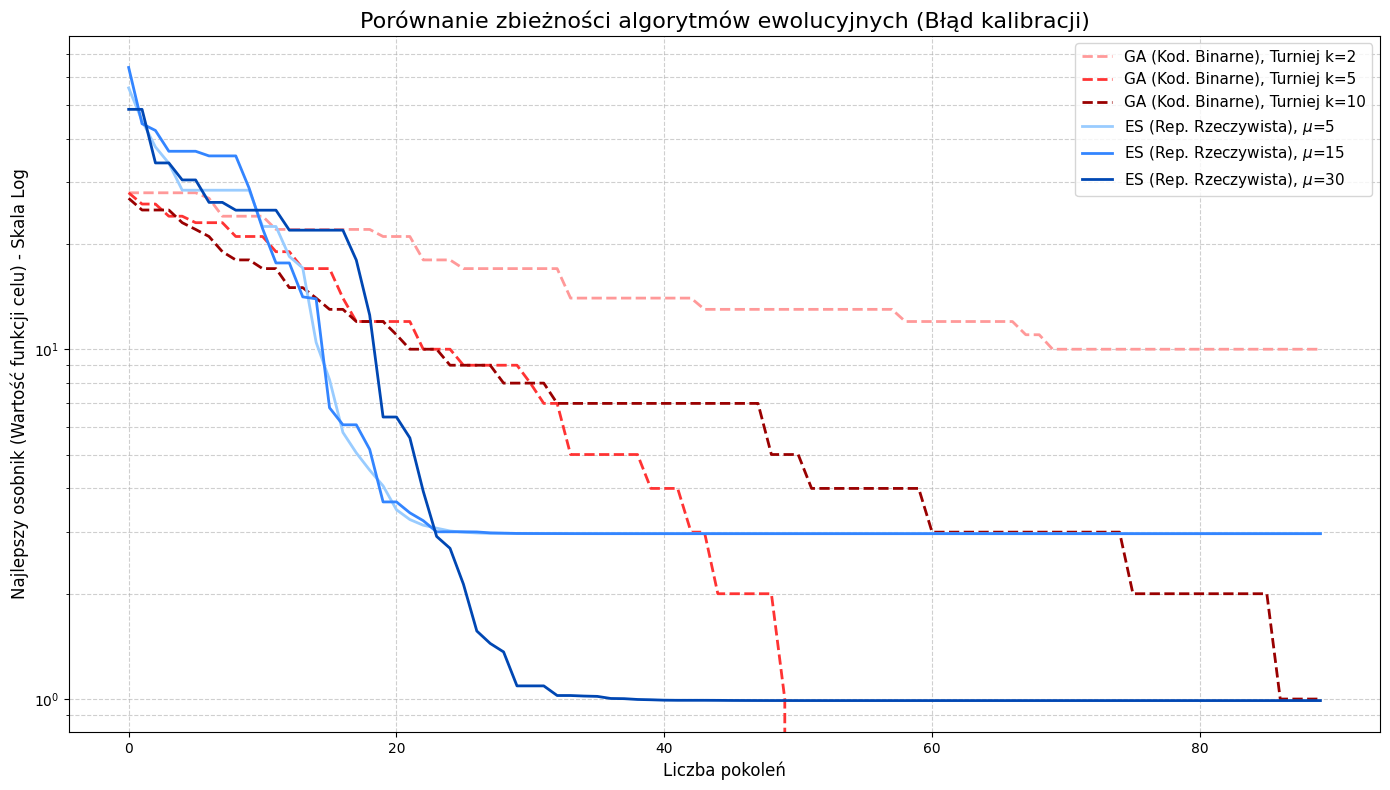

In [12]:
plt.figure(figsize=(14, 8))

# Rysowanie wykresów dla Algorytmu Genetycznego (SGA)
colors_ga = ['#ff9999', '#ff3333', '#990000']
for (k, history), color in zip(ga_results_history.items(), colors_ga):
    plt.plot(history, label=f'GA (Kod. Binarne), Turniej k={k}', linestyle='--', color=color, linewidth=2)

# Rysowanie wykresów dla Strategii Ewolucyjnej (ES)
colors_es = ['#99ccff', '#3385ff', '#0047b3']
for (mu, history), color in zip(es_results_history.items(), colors_es):
    plt.plot(history, label=rf'ES (Rep. Rzeczywista), $\mu$={mu}', linestyle='-', color=color, linewidth=2)

plt.title('Porównanie zbieżności algorytmów ewolucyjnych (Błąd kalibracji)', fontsize=16)
plt.xlabel('Liczba pokoleń', fontsize=12)
plt.ylabel('Najlepszy osobnik (Wartość funkcji celu) - Skala Log', fontsize=12)
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Wnioski i Interpretacja

**1. Różnice między reprezentacjami (Binarna vs Rzeczywista):**
* Strategia ewolucyjna (Przypadek B) korzystająca z reprezentacji rzeczywistej i mutacji gaussowskiej zazwyczaj osiąga znacznie lepsze (niższe) wyniki na funkcjach ciągłych z wieloma minimami lokalnymi (takich jak rozpatrywana funkcja Rastrigina) niż klasyczny wariant binarny. Wynika to z faktu, że mechanizm samoadaptacji parametru $\sigma$ potrafi dynamicznie zmniejszać promień przeszukiwania, gdy algorytm zbliża się do optymalnego rozwiązania (tzw. eksploatacja).
* Algorytm binarny (Przypadek A) cierpi z powodu tzw. "szumu precyzji" – operuje na 8 bitach co mocno kwantuje przestrzeń rozwiązań, uniemożliwiając precyzyjne dotarcie do idealnego zera. *(Uwaga techniczna do implementacji: Metoda `decode_genes` zrzuca aktualnie wartości binarne do typu `int(..., 2)` [0-255]. Rzeczywista funkcja osiąga optimum przy `x_i = 0`. Stąd wartości GA mogą wydawać się nienaturalnie wysokie, dopóki nie dodamy odpowiedniego skalowania do przedziału np. [-5.12, 5.12]).*

**2. Analiza parametrów - Rozmiar turnieju ($k$) w GA:**
* Małe $k$ (np. 2): Mniejsza presja selekcyjna. Algorytm eksploruje szerzej, ale zbiega wolniej.
* Duże $k$ (np. 10): Bardzo silna presja selekcyjna. Promuje najlepszych, co przyspiesza spadek błędu w pierwszych pokoleniach, ale zwiększa ryzyko przedwczesnej zbieżności (utknięcia w minimum lokalnym).

**3. Analiza parametrów - Próg selekcji ($\mu$) w ES:**
* Niskie $\mu$ (np. 5): Bardzo "zachłanna" strategia. Z populacji potomnej 100 osobników wybieranych jest zaledwie 5 najlepszych do reprodukcji. Pozwala to na gwałtowny spadek błędu, ale drastycznie redukuje różnorodność genetyczną.
* Wyższe $\mu$ (np. 30): Bardziej zrównoważone podejście. Przekazanie większej puli osobników do krzyżowania arytmetycznego sprawia, że algorytm zachowuje więcej różnorodności, radząc sobie lepiej z wychodzeniem z lokalnych minimów kosztem początkowej szybkości zbiegania.